In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

In [2]:
df_gas = pd.read_csv('aaa_fl_metros_wayback_2022_2025.csv')
df_gas[['regular','mid','premium','diesel']] = (
    df_gas[['regular','mid','premium','diesel']].round(3))


FileNotFoundError: [Errno 2] No such file or directory: 'aaa_fl_metros_wayback_2022_2025.csv'

In [ ]:
df_gas = df_gas.drop(columns = 'wayback_timestamp')

In [ ]:
df_gas = df_gas.drop_duplicates()
df_gas

,date,metro,label,regular,mid,premium,diesel
0,2022-01-28,Bradenton-Sarasota-Venice,Current Avg.,3.351,3.731,4.006,3.716
1,2022-01-28,Bradenton-Sarasota-Venice,Yesterday Avg.,3.348,3.709,4.003,3.711
2,2022-01-28,Bradenton-Sarasota-Venice,Week Ago Avg.,3.236,3.625,3.915,3.563
3,2022-01-28,Bradenton-Sarasota-Venice,Month Ago Avg.,3.213,3.602,3.899,3.478
4,2022-01-28,Bradenton-Sarasota-Venice,Year Ago Avg.,2.366,2.726,3.014,2.617
...,...,...,...,...,...,...,...
57715,2025-12-30,The Villages,Current Avg.,2.801,3.267,3.590,3.474
57716,2025-12-30,The Villages,Yesterday Avg.,2.683,3.033,3.422,3.509
57717,2025-12-30,The Villages,Week Ago Avg.,2.808,3.231,3.555,3.540
57718,2025-12-30,The Villages,Month Ago Avg.,2.975,3.384,3.725,3.741


In [ ]:
df_gas.loc[2]

date                      2022-01-28
metro      Bradenton-Sarasota-Venice
label                  Week Ago Avg.
regular                        3.236
mid                            3.625
premium                        3.915
diesel                         3.563
Name: 2, dtype: object

In [ ]:
df_gas['date'] = pd.to_datetime(df_gas['date'])
df_gas['date'].dtype

dtype('<M8[ns]')

In [ ]:
df_gas = df_gas.sort_values(['metro', 'date'])
df_gas.head()

,date,metro,label,regular,mid,premium,diesel
0,2022-01-28,Bradenton-Sarasota-Venice,Current Avg.,3.351,3.731,4.006,3.716
1,2022-01-28,Bradenton-Sarasota-Venice,Yesterday Avg.,3.348,3.709,4.003,3.711
2,2022-01-28,Bradenton-Sarasota-Venice,Week Ago Avg.,3.236,3.625,3.915,3.563
3,2022-01-28,Bradenton-Sarasota-Venice,Month Ago Avg.,3.213,3.602,3.899,3.478
4,2022-01-28,Bradenton-Sarasota-Venice,Year Ago Avg.,2.366,2.726,3.014,2.617


In [ ]:
#Change date of "yesterday avg." and "week ago avg.". remove month ago avg.

mask = df_gas['label'] =='Yesterday Avg.'
df_gas.loc[mask, 'date'] = df_gas.loc[mask,'date'] - timedelta(days=1)

mask2 = df_gas['label'] == 'Week Ago Avg.'
df_gas.loc[mask2, 'date'] = df_gas.loc[mask2, 'date'] - timedelta(days=7)

mask3 = (df_gas['label'] == 'Month Ago Avg.') | (df_gas['label'] == 'Year Ago Avg.')
df_gas = df_gas.loc[~mask3]

df_gas

,date,metro,label,regular,mid,premium,diesel
0,2022-01-28,Bradenton-Sarasota-Venice,Current Avg.,3.351,3.731,4.006,3.716
1,2022-01-27,Bradenton-Sarasota-Venice,Yesterday Avg.,3.348,3.709,4.003,3.711
2,2022-01-21,Bradenton-Sarasota-Venice,Week Ago Avg.,3.236,3.625,3.915,3.563
120,2022-03-07,Bradenton-Sarasota-Venice,Current Avg.,4.005,4.292,4.603,4.559
121,2022-03-06,Bradenton-Sarasota-Venice,Yesterday Avg.,3.950,4.228,4.525,4.526
...,...,...,...,...,...,...,...
57531,2025-12-28,West Palm Beach-Boca Raton,Yesterday Avg.,2.912,3.333,3.692,3.626
57532,2025-12-22,West Palm Beach-Boca Raton,Week Ago Avg.,3.027,3.486,3.822,3.627
57650,2025-12-30,West Palm Beach-Boca Raton,Current Avg.,2.954,3.405,3.757,3.610
57651,2025-12-29,West Palm Beach-Boca Raton,Yesterday Avg.,2.901,3.304,3.679,3.615


In [ ]:
df_gas = df_gas.drop(columns = ['label'])
df_gas.head()

,date,metro,regular,mid,premium,diesel
0,2022-01-28,Bradenton-Sarasota-Venice,3.351,3.731,4.006,3.716
1,2022-01-27,Bradenton-Sarasota-Venice,3.348,3.709,4.003,3.711
2,2022-01-21,Bradenton-Sarasota-Venice,3.236,3.625,3.915,3.563
120,2022-03-07,Bradenton-Sarasota-Venice,4.005,4.292,4.603,4.559
121,2022-03-06,Bradenton-Sarasota-Venice,3.950,4.228,4.525,4.526


In [ ]:

df_gas = df_gas.sort_values(['metro', 'date'])
df_gas = df_gas.drop_duplicates()

df_gas

,date,metro,regular,mid,premium,diesel
2,2022-01-21,Bradenton-Sarasota-Venice,3.236,3.625,3.915,3.563
1,2022-01-27,Bradenton-Sarasota-Venice,3.348,3.709,4.003,3.711
0,2022-01-28,Bradenton-Sarasota-Venice,3.351,3.731,4.006,3.716
122,2022-02-28,Bradenton-Sarasota-Venice,3.502,3.862,4.164,3.933
242,2022-03-01,Bradenton-Sarasota-Venice,3.502,3.862,4.164,3.933
...,...,...,...,...,...,...
57411,2025-12-26,West Palm Beach-Boca Raton,2.930,3.387,3.719,3.626
57410,2025-12-27,West Palm Beach-Boca Raton,2.917,3.350,3.682,3.626
57531,2025-12-28,West Palm Beach-Boca Raton,2.912,3.333,3.692,3.626
57530,2025-12-29,West Palm Beach-Boca Raton,2.901,3.304,3.679,3.615


<Axes: xlabel='date'>

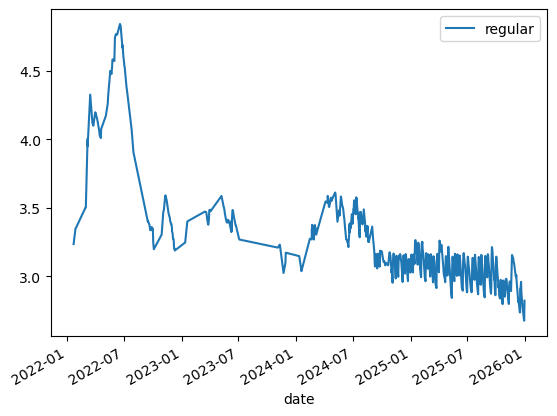

In [ ]:
df_BSV = df_gas[df_gas['metro']=='Bradenton-Sarasota-Venice']
df_BSV.plot(x='date', y = 'regular')

In [ ]:
#interpolate 

df_daily = (df_gas
            .set_index('date')
            .groupby('metro')
            .resample('D')
            .mean()
            .interpolate('linear')
           .reset_index())

df_daily.groupby('metro').plot(x = 'date', y = 'regular')